### **1. Import necessary libraries and modules**

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Flatten, Dense, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import os

from custom_loss_functions import SCCE, SCCEInverse, SCCEMinMaxBin, SCCEMaxBin, SCCEDifference, SCCEMaxBinL2
from custom_layers import QuantizedDataLayer, QuantizedDenseLayer, CustomDenseLayerNew
from custom_callbacks import QuantizedDataTrackingCallback, NestedScaleTrackingCallbackNew
from utils import print_model_structure, count_unique_values, count_unique_values_and_plot_histograms, count_unique_values_2

from datetime import datetime

from plot_scripts import plot_loss

### **2. Import MNIST data:**

In [2]:
# Prepare the data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = np.expand_dims(x_train, -1)  # CNNs typically expect input data to be 4D
x_test = np.expand_dims(x_test, -1)

In [3]:
def initialize_loss_function(model, penalty_rate, log_dir, loss_func = SCCEMaxBinL2):
    # Initialize your custom loss function
    loss_function = loss_func(
        layers=[model.get_layer(index=2), model.get_layer(index=3)],
        penalty_rate=penalty_rate,
        log_dir = log_dir
    )
    return loss_function


In [4]:
# Only input data is quantized
def initialize_quantized_data_model(input_shape = (28,28,1)):
    input_layer = Input(shape=(28,28,1))
    flatten_layer = Flatten()(input_layer)

    input_q = QuantizedDataLayer(initializer=None)(flatten_layer)

    dense_layer = Dense(128)
    dense_layer_output = dense_layer(input_q)
    dense_layer_activation = tf.keras.activations.relu(dense_layer_output)

    dense_layer_2 = Dense(10)
    dense_layer_2_output = dense_layer_2(dense_layer_activation)
    dense_layer_2_activation = tf.keras.activations.softmax(dense_layer_2_output)

    quantized_model = Model(inputs=input_layer, outputs=dense_layer_2_activation)

    return quantized_model    

In [5]:
# Only weights of the first layer
def initialize_quantized_weights_model(input_shape = (28,28,1)):
    print("TESTING")
    input_layer = Input(shape=(28,28,1))
    flatten_layer = Flatten()(input_layer)

    input_quantized = QuantizedDataLayer(initializer=None)(flatten_layer)

    dense_layer = CustomDenseLayerNew(128)
    dense_layer_output = dense_layer(input_quantized)

    dense_layer_activation = tf.keras.activations.relu(dense_layer_output)

#    dense_layer_2 = Dense(10)
    dense_layer_2 = CustomDenseLayerNew(10)
    dense_layer_2_output = dense_layer_2(dense_layer_activation)
    dense_layer_2_activation = tf.keras.activations.softmax(dense_layer_2_output)

    quantized_model = Model(inputs=input_layer, outputs=dense_layer_2_activation)

    return quantized_model    


In [6]:
def prepare_model_dir(model, penalty_rate, run_timestamp):
    log_dir = f'logs/{run_timestamp}_pr_{penalty_rate}'
    os.makedirs(log_dir)
    print_model_structure(model, log_dir, filename="quantized_model_structure.txt")
    return log_dir

In [7]:
def compile_model(model, learning_rate, loss_function=None):
    # Compile your models
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
#        loss=loss_function.compute_total_loss,
        loss="sparse_categorical_crossentropy",
        metrics=['accuracy']
    )

In [8]:
def train_model(model, epochs, validation_data, batch_size, **callbacks):
    # Train your model
    model.fit(
        x_train, y_train,
        epochs=epochs,
        validation_data=validation_data,
        callbacks=list(callbacks.values()),  
        batch_size=batch_size
    )

In [9]:
def evaluate_model(model):
    loss, accuracy = model.evaluate(x_test, y_test)
    print(f'Quantized Model Test Accuracy: {accuracy}')
    return accuracy

In [10]:
def initialize_callbacks(model, log_dir, validation_data):
    # Initialize your callbacks
    quantized_input_tracker = QuantizedDataTrackingCallback(model.get_layer(index=2), log_dir)
    scale_tracking_callback_first_dense_layer = NestedScaleTrackingCallbackNew(model.get_layer(index=3), log_dir)
    scale_tracking_callback_second_dense_layer = NestedScaleTrackingCallbackNew(model.get_layer(index=4), log_dir)

    # Return callbacks as a dictionary
    callbacks = {
        'quantized_input_tracker': quantized_input_tracker,
        'scale_tracking_callback_first_dense_layer': scale_tracking_callback_first_dense_layer,
        'scale_tracking_callback_second_dense_layer': scale_tracking_callback_second_dense_layer,

    }

    return callbacks


In [11]:
#penalty_rate = [round(x * 0.02 + 0.1, 2) for x in range(45)]
penalty_rates = [
    0.0,
]

learning_rate = 0.001
validation_data = (x_test, y_test)
epochs = 30
val_interval = 75
batch_size = 32
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

log_dirs = []

for pr in penalty_rates:
    
    quantized_model = initialize_quantized_weights_model(input_shape=(28,28,1))

    log_dir = prepare_model_dir(model=quantized_model, penalty_rate=pr, run_timestamp = run_timestamp)
    log_dirs.append(log_dir)

#    loss_function = initialize_loss_function(
#        model=quantized_model, 
#        penalty_rate=pr, 
#        log_dir=log_dir
#    )

    compile_model(
        model=quantized_model, 
        learning_rate=learning_rate, 
#        loss_function=loss_function
    )

    callbacks = initialize_callbacks(quantized_model, log_dir, validation_data)
    #callbacks = {}

    train_model(
        model=quantized_model, 
        epochs=epochs, 
        validation_data=validation_data,
        batch_size=batch_size,
        **callbacks
    )

    accuracy = evaluate_model(model=quantized_model)

TESTING
W shape (784, 128)
b shape (128,)
W shape (128, 10)
b shape (10,)

--------------------------------------------------------------------------------
MODEL STRUCTURE

LAYER 0: <InputLayer name=input_layer, built=True>
  - Input Shape: []
  - Output Shape: <KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, name=keras_tensor>

LAYER 1: <Flatten name=flatten, built=True>
  - Input Shape: <KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, name=keras_tensor>
  - Output Shape: <KerasTensor shape=(None, 784), dtype=float32, sparse=False, name=keras_tensor_1>

LAYER 2: <QuantizedDataLayer name=quantized_data_layer, built=True>
  - Input Shape: <KerasTensor shape=(None, 784), dtype=float32, sparse=False, name=keras_tensor_1>
  - Output Shape: <KerasTensor shape=(None, 784), dtype=float32, sparse=False, name=keras_tensor_2>

LAYER 3: <CustomDenseLayerNew name=custom_dense_layer_new, built=True>
  - Input Shape: <KerasTensor shape=(None, 784), dtype=float32, 

In [12]:
print(log_dir)

logs/2024-11-05_08-37-32_pr_0.0


In [13]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np

def plot_values_of_trainable_parameters(log_dir, log_files):
    for log_file in log_files:

        log_file_title = log_file.split(".")[0]

        # Define paths to the log files
        log_file_path_w = f"{log_dir}/{log_file}"

        def process_log_file(file_path):
            all_values = []
            epochs = []
            current_values = []
            
            with open(file_path, 'r') as file:
                for line in file:
                    line = line.strip()
                    
                    if line.startswith('Epoch'):
                        current_epoch = int(line.split()[1])
                        epochs.append(current_epoch)

                        if current_epoch != 0:
                            all_values.append(current_values)
                            current_values = []
                    else:
                        value = float(line)
                        current_values.append(value)

            all_values.append(current_values)
            return all_values

        # Process both log files
        all_values_w = process_log_file(log_file_path_w)

        # Plot for scale_w
        plt.figure(figsize=(12, 8))
        for i in range(len(all_values_w[0])):
            scale_trajectory = [epoch[i] for epoch in all_values_w]
            plt.plot(range(1, len(all_values_w) + 1), scale_trajectory, linestyle='-', marker='o', label=f'scale_w_{i}')
        
        plt.xlabel('Epochs')
        plt.ylabel('Values')
        plt.title(f'{log_file_title}')
        plt.xticks(range(1, len(all_values_w) + 1))
        
        plots_dir = os.path.join(log_dir, 'plots')
        os.makedirs(plots_dir, exist_ok=True)
        plt.savefig(os.path.join(plots_dir, f'{log_file_title}.png'))
        
        plt.show()

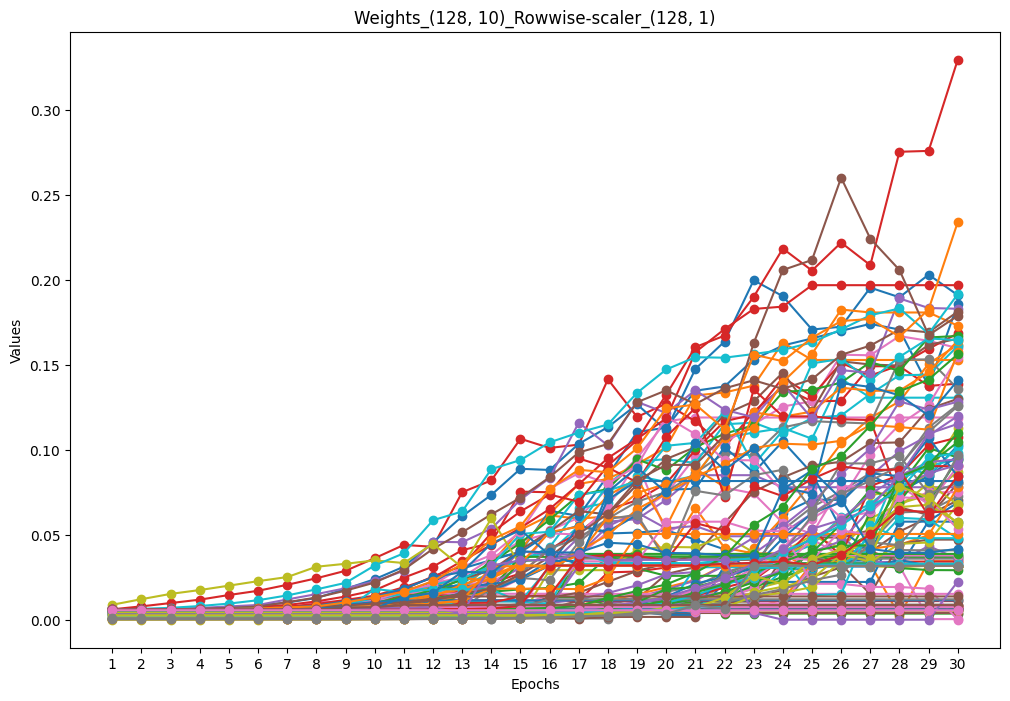

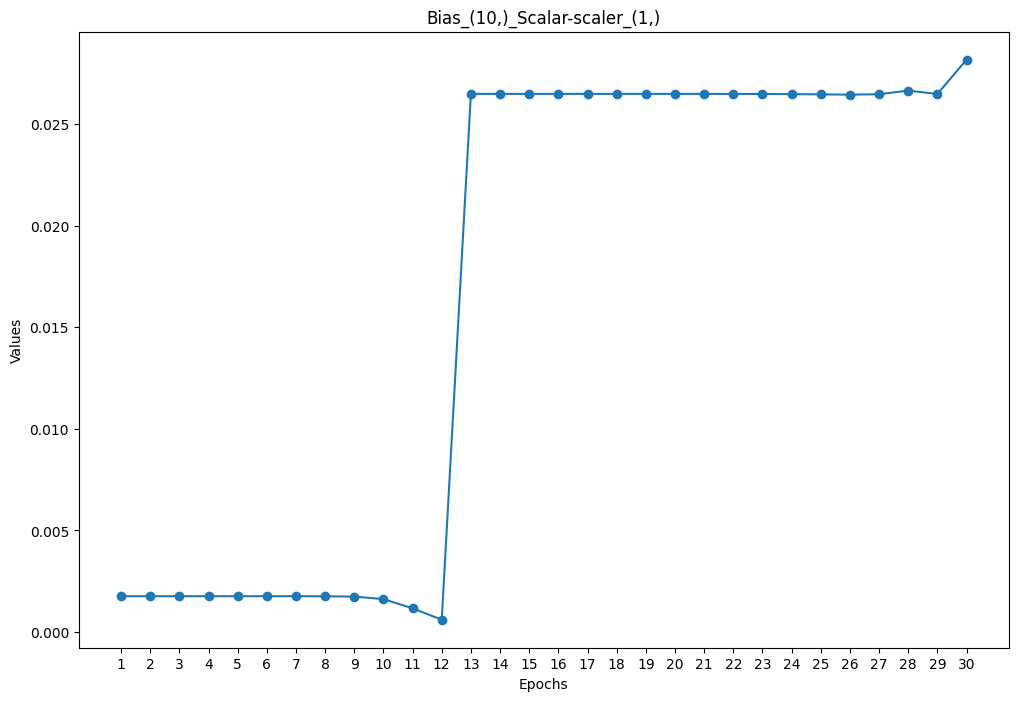

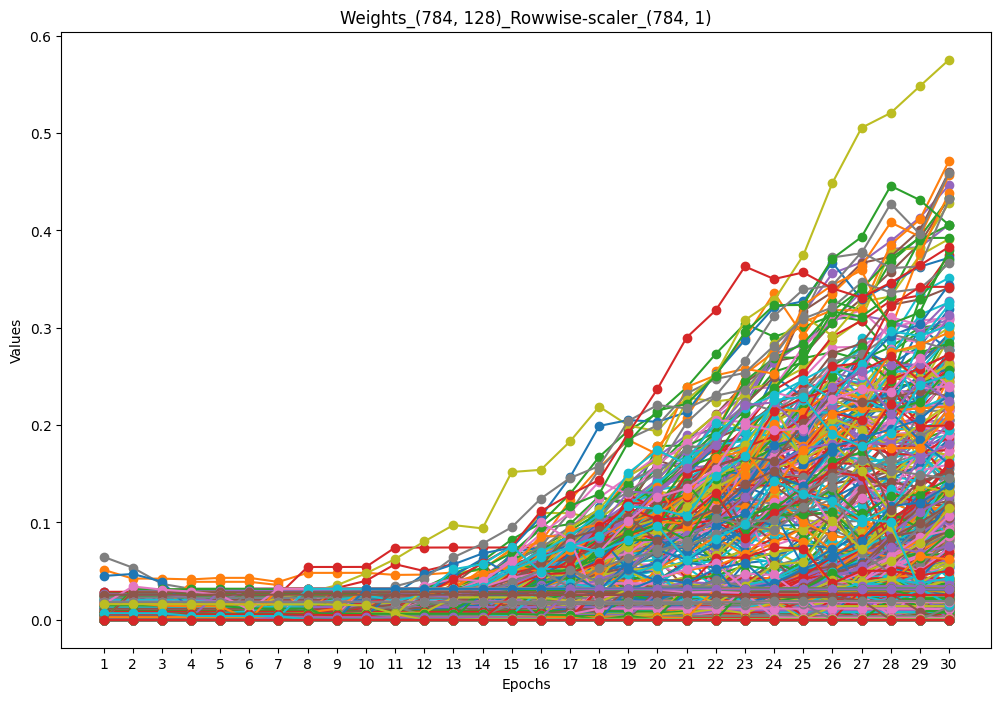

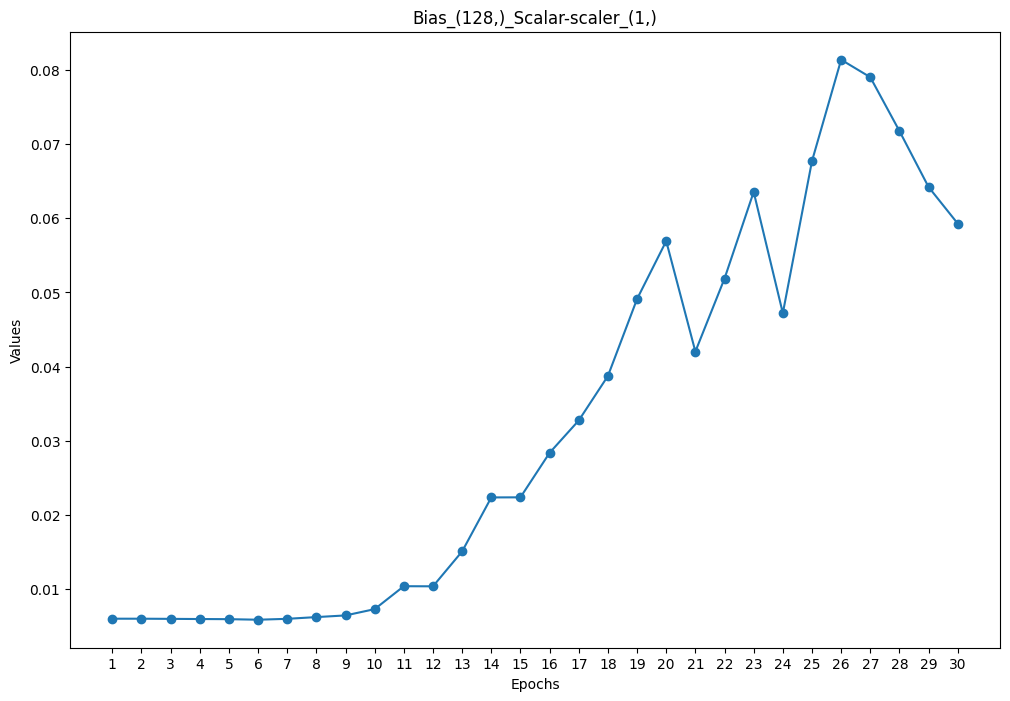

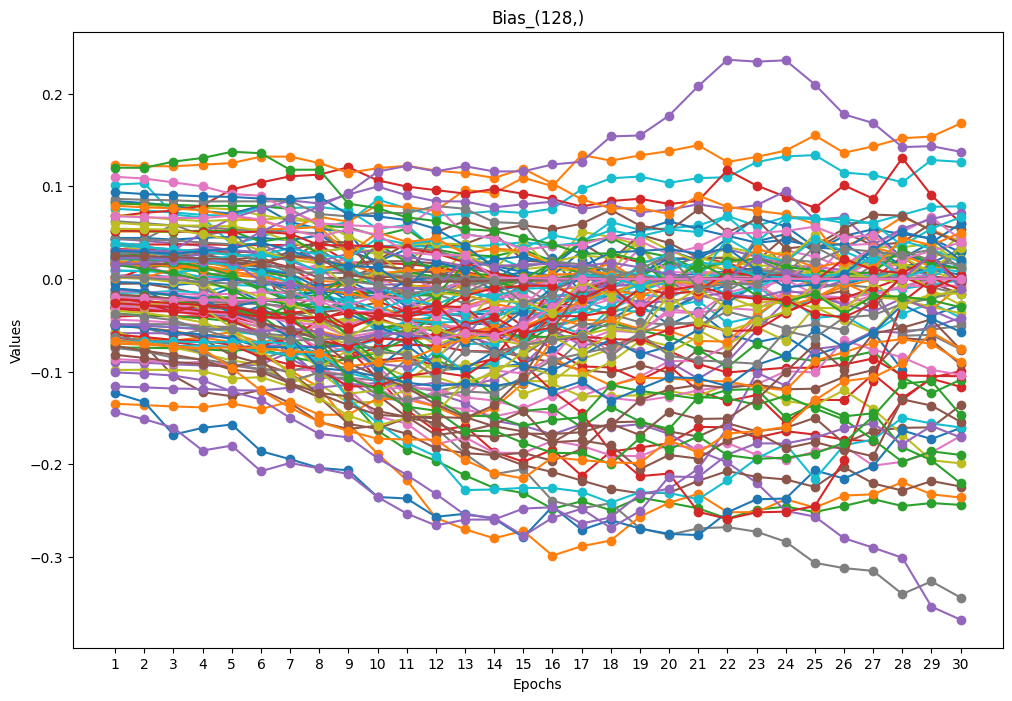

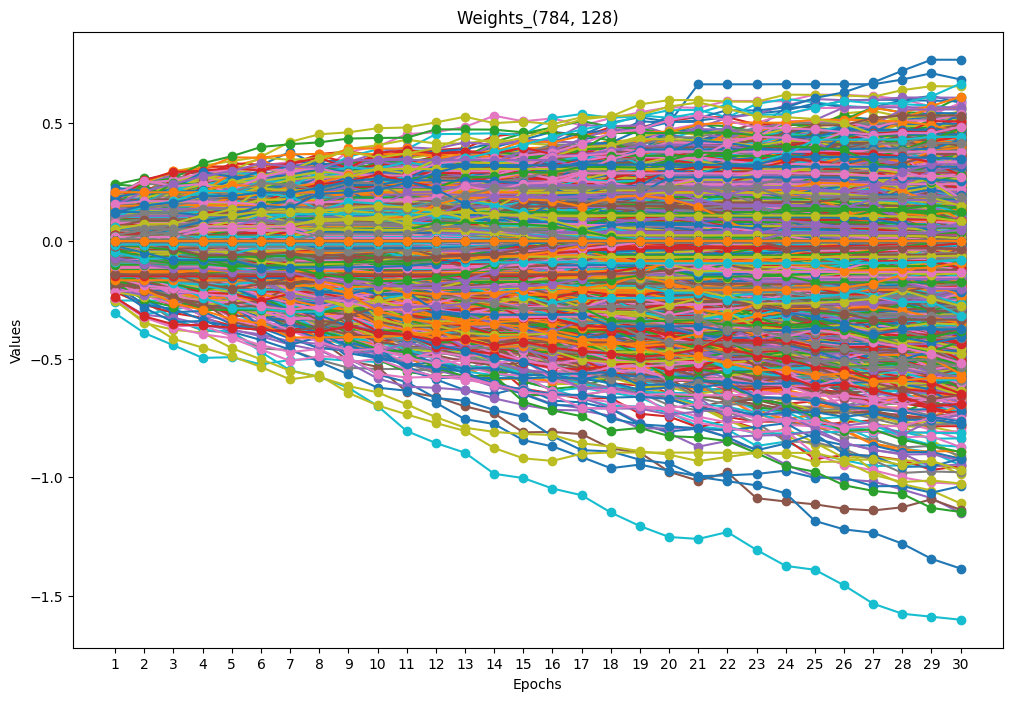

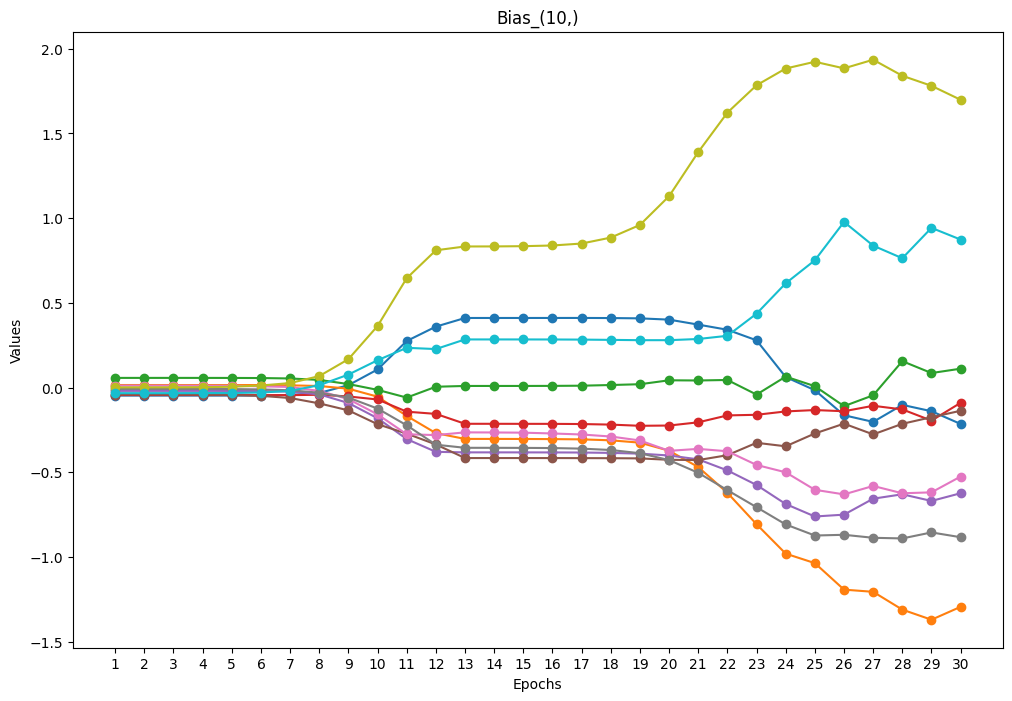

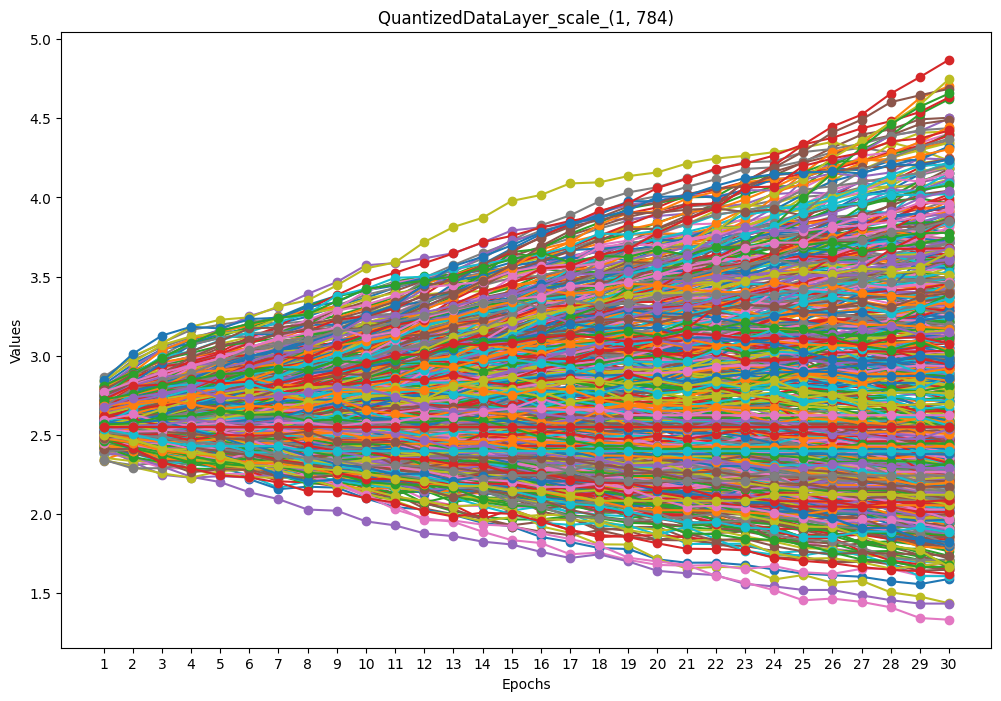

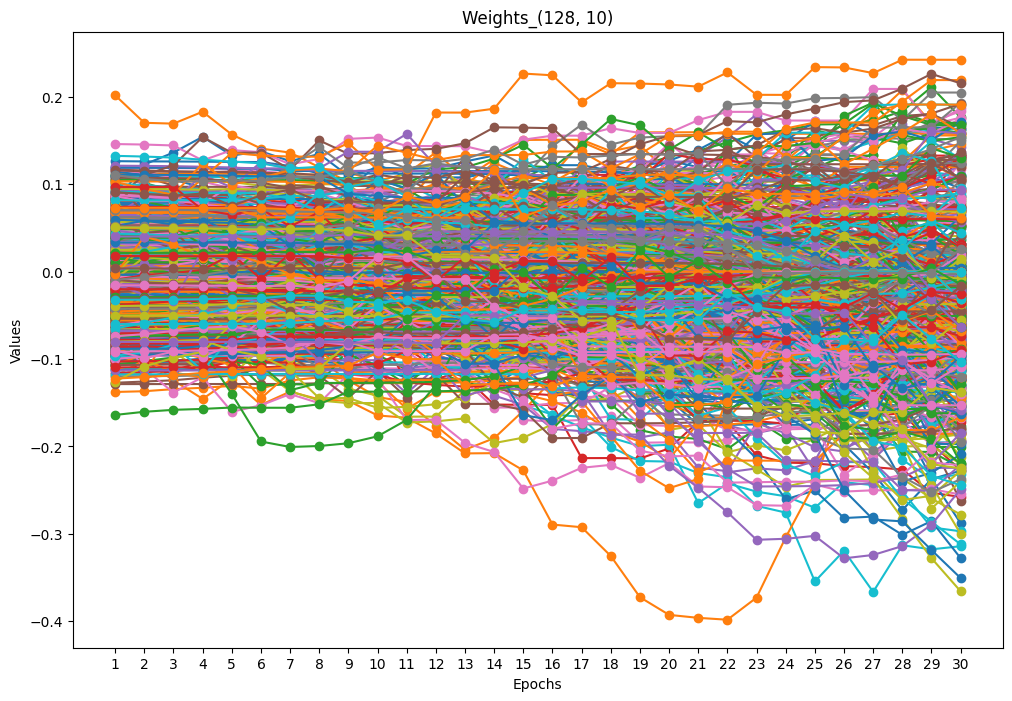

In [14]:
file_list = os.listdir(log_dir)
file_list = [f for f in file_list if os.path.isfile(os.path.join(log_dir, f)) and f[-3:]=="log" and "Quantized_" not in f]
plot_values_of_trainable_parameters(log_dir, file_list)

['Quantized_Bias_(128,)_Scalar-scaler_(1,).log', 'Quantized_Weights_(784, 128)_Rowwise-scaler_(784, 1).log', 'Quantized_Weights_(128, 10)_Rowwise-scaler_(128, 1).log', 'Quantized_Bias_(10,)_Scalar-scaler_(1,).log']


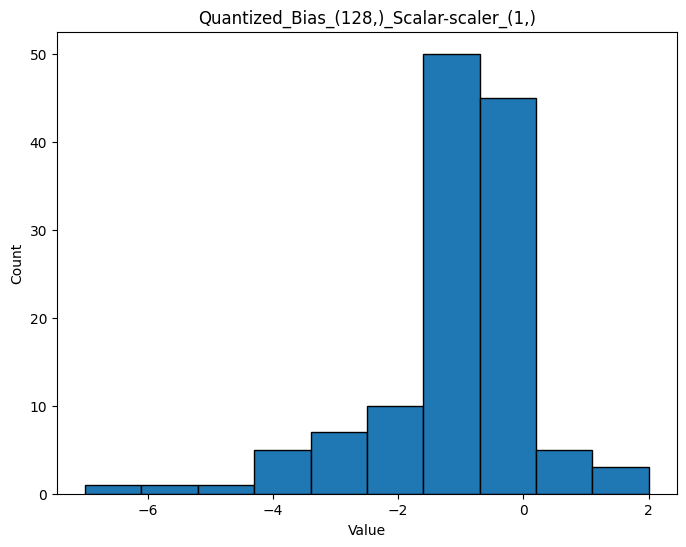

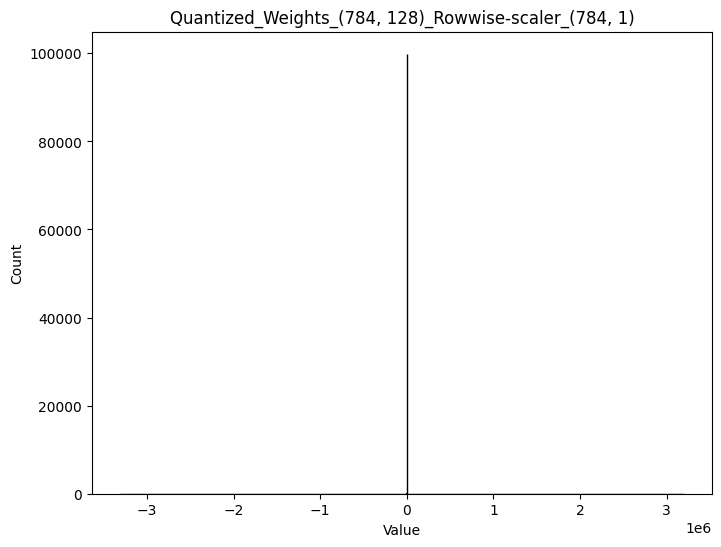

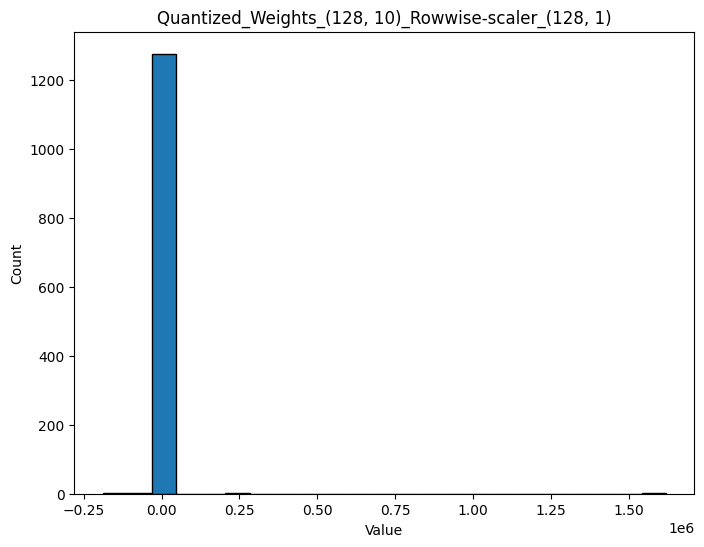

[-8.0, -46.0, 3.0, -4.0, -23.0, -5.0, -19.0, -32.0, 60.0, 31.0]


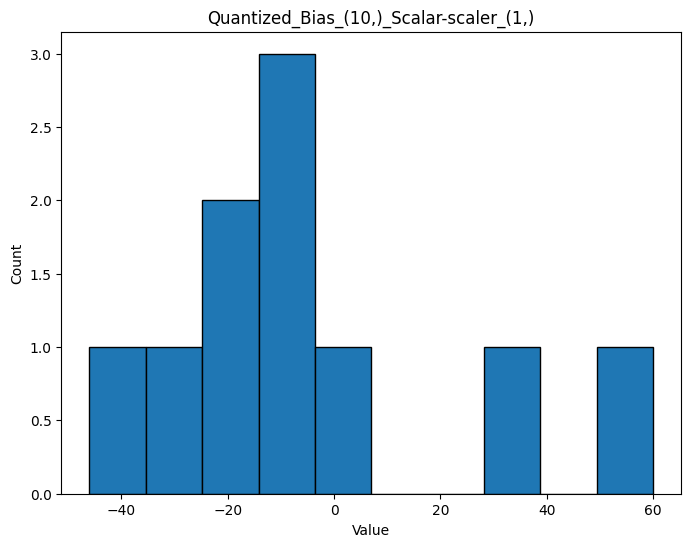

In [15]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np

def plot_quantized_values(log_dir, log_files):

    def process_log_file(file_path):
        all_values = []
        
        with open(file_path, 'r') as file:
            for line in file:
                line = line.strip()
                value = float(line)
                all_values.append(value)

        return all_values

    for log_file in log_files:

        log_file_path = f"{log_dir}/{log_file}"

        values = process_log_file(log_file_path)

        log_file_title = log_file.split(".")[0]

        if len(values) == 10:
            print(values)

        plt.figure(figsize=(8, 6))
        plt.hist(values, bins=len(set(values)), edgecolor='black')  # Each unique value gets its own bin
        plt.title(f'{log_file_title}')
        plt.xlabel('Value')
        plt.ylabel('Count')

        plots_dir = os.path.join(log_dir, 'plots')
        os.makedirs(plots_dir, exist_ok=True)
        plt.savefig(os.path.join(plots_dir, f'{log_file_title}.png'))
        
        unique_values = set(values)

        plots_dir = os.path.join(log_dir, 'unique_values')
        os.makedirs(plots_dir, exist_ok=True)
        # Save unique values to a file, each on a new line
        with open(os.path.join(plots_dir, f'{log_file_title}.txt'), 'w') as file:
            for value in unique_values:
                file.write(f"{value}\n")

        plt.show()
file_list = os.listdir(log_dir)
quantized_file_list = [f for f in file_list if os.path.isfile(os.path.join(log_dir, f)) and f[-3:]=="log" and "Quantized_" in f]
print(quantized_file_list)
plot_quantized_values(log_dir, quantized_file_list)

In [16]:

def plot_quantized_data(log_dir, log_files):
    for log_file in log_files:

        log_file_title = log_file.split(".")[0]

        # Define paths to the log files
        log_file_path_w = f"{log_dir}/{log_file}"

        def process_log_file(file_path):
            all_values = []
            epochs = []
            current_values = []
            
            with open(file_path, 'r') as file:
                for line in file:
                    line = line.strip()
                    
                    if line.startswith('Epoch'):
                        current_epoch = int(line.split()[1])
                        epochs.append(current_epoch)

                        if current_epoch != 0:
                            all_values.append(current_values)
                            current_values = []
                    else:
                        value = float(line)
                        current_values.append(value)

            all_values.append(current_values)
            return all_values

        # Process both log files
        all_values = process_log_file(log_file_path_w)
        last_values = all_values[-1]
        print(len(last_values))

        quantized_data = []

        for sample in x_train:
            flattened_sample = sample.flatten()

            result = [np.floor(fs / lv) for fs, lv in zip(flattened_sample, last_values)]
            quantized_data += result

        unique_quantized_data_values = set(quantized_data)

#        plt.figure(figsize=(8, 6))
#        plt.hist(quantized_data, bins=len(set(quantized_data)), edgecolor='black')  # Each unique value gets its own bin
#        plt.title(f'{log_file_title}')
#        plt.xlabel('Value')
#        plt.ylabel('Count')

#        plots_dir = os.path.join(log_dir, 'plots')
#        os.makedirs(plots_dir, exist_ok=True)
#       plt.savefig(os.path.join(plots_dir, f'{log_file_title}.png'))

#        plt.show()
        
        plots_dir = os.path.join(log_dir, 'unique_values')
        os.makedirs(plots_dir, exist_ok=True)
        # Save unique values to a file, each on a new line
        with open(os.path.join(plots_dir, f'{log_file_title}.txt'), 'w') as file:
            for value in unique_quantized_data_values:
                file.write(f"{value}\n")


file_list = os.listdir(log_dir)
quantized_file_list = [f for f in file_list if os.path.isfile(os.path.join(log_dir, f)) and f[-3:]=="log" and "QuantizedData" in f]
print(quantized_file_list)
plot_quantized_data(log_dir, quantized_file_list)

['QuantizedDataLayer_scale_(1, 784).log']
784
